# 5. Spatially Correlated Gaussian Noise

In the previous notebooks, the stochastic heat equation was driven by space-time white noise, whose values are independent at different spatial locations.

In many applications, however, nearby points are spatially correlated. In this notebook, we replace white noise by spatially correlated Gaussian noise and construct realizations with a prescribed covariance structure.

We also verify numerically that the generated random fields possess the desired covariance.

## Objectives

In this notebook we will

- introduce spatially correlated Gaussian noise,
- construct covariance matrices on a periodic domain,
- generate correlated Gaussian samples using the Cholesky decomposition,
- investigate the effect of the correlation length, and
- verify the prescribed covariance numerically.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Spatial grid
N = 100
h = 1 / N
x = np.arange(N) * h

## Mathematical Background

### Spatially Correlated Gaussian Noise

Unlike space-time white noise, spatially correlated Gaussian noise allows nearby spatial locations to exhibit statistical dependence.

Throughout this notebook, we prescribe the covariance function

$$
Q(x,y)
=
\exp\!\left(
-\frac{d(x,y)}{\ell}
\right),
$$

where $d(x,y)$ is the periodic distance on the unit interval and $\ell>0$ is the correlation length.

Smaller values of $\ell$ correspond to weaker spatial correlation, while larger values produce smoother random fields.

In [3]:
def covariance_matrix(x, ell):
    """
    Construct the exponential covariance matrix
    on a one-dimensional periodic domain.
    """
    N = len(x)
    h = x[1] - x[0]
    domain_length = N * h

    Q = np.zeros((N, N))

    for i in range(N):
        for j in range(N):
            distance = abs(x[i] - x[j])
            periodic_distance = min(
                distance,
                domain_length - distance,
            )

            Q[i, j] = np.exp(
                -periodic_distance / ell
            )

    return Q

### Cholesky Transformation

Let

$$
Q=LL^\top
$$

be the Cholesky decomposition of the covariance matrix.

If

$$
Z\sim\mathcal N(0,I),
$$

then

$$
Y=LZ
$$

is a Gaussian random vector satisfying

$$
\operatorname{Cov}(Y)=Q.
$$

This provides a numerical procedure for generating Gaussian random fields with covariance $Q$.

In [4]:
def generate_colored_noise(L, white_sample):
    """
    Transform a standard Gaussian vector into
    a Gaussian vector with covariance matrix L @ L.T.
    """
    return L @ white_sample

## Numerical Experiments

### Covariance Structure

We first construct covariance matrices for several correlation lengths in order to visualize how the prescribed covariance changes as $\ell$ varies.

In [5]:
ells = [0.01, 0.05, 0.20]

### Covariance Matrices

The following figure shows the covariance matrices corresponding to different correlation lengths.

As the correlation length increases, the covariance extends farther away from the diagonal, indicating stronger dependence between distant spatial locations.

In [6]:
covariance_matrices = {
    ell: covariance_matrix(x, ell)
    for ell in ells
}

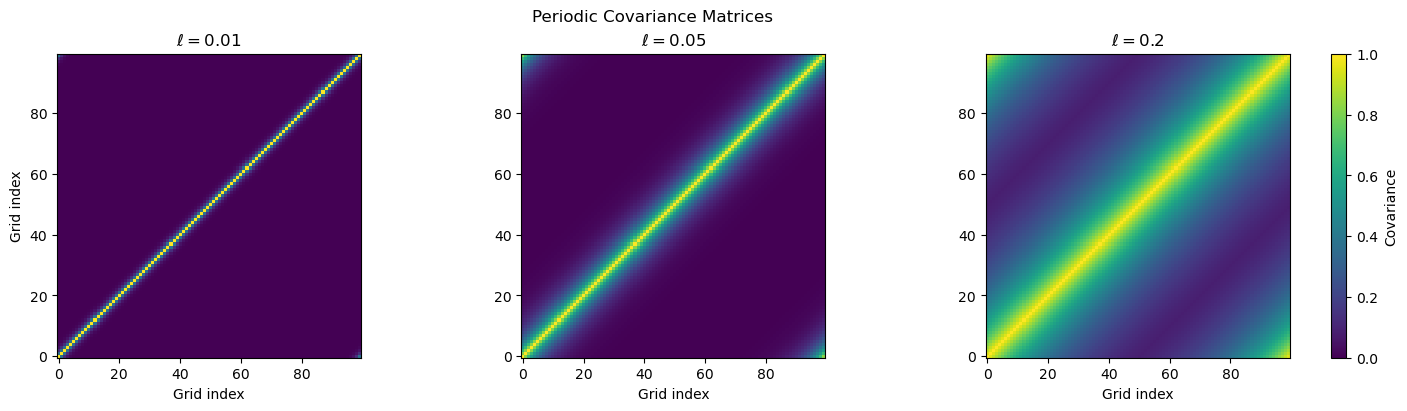

In [7]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4),
    constrained_layout=True,
)

for ax, ell in zip(axes, ells):
    image = ax.imshow(
        covariance_matrices[ell],
        origin="lower",
        aspect="equal",
        vmin=0,
        vmax=1,
    )

    ax.set_title(rf"$\ell={ell}$")
    ax.set_xlabel("Grid index")

axes[0].set_ylabel("Grid index")

fig.colorbar(
    image,
    ax=axes,
    fraction=0.035,
    pad=0.03,
    label="Covariance",
)

fig.suptitle("Periodic Covariance Matrices")
plt.show()

### Covariance Profiles

To better visualize the covariance function, we plot one row of each covariance matrix.

These profiles illustrate how the covariance decays with the periodic distance from a fixed spatial location.

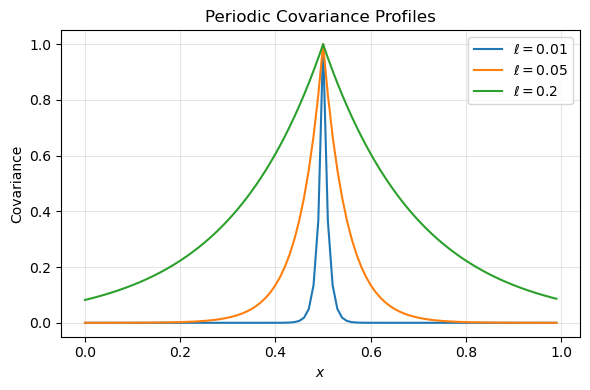

In [8]:
reference_index = N // 2

plt.figure(figsize=(6, 4))

for ell in ells:
    plt.plot(
        x,
        covariance_matrices[ell][reference_index],
        label=rf"$\ell={ell}$",
    )

plt.xlabel(r"$x$")
plt.ylabel("Covariance")
plt.title("Periodic Covariance Profiles")

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Gaussian Samples

We next generate one realization of standard Gaussian white noise and transform it into spatially correlated Gaussian noise using the Cholesky decomposition.

The same white-noise realization is used for every correlation length.

In [9]:
rng = np.random.default_rng(42)

white_sample = rng.normal(size=N)

cholesky_factors = {
    ell: np.linalg.cholesky(covariance_matrices[ell])
    for ell in ells
}

colored_samples = {
    ell: generate_colored_noise(
        cholesky_factors[ell],
        white_sample,
    )
    for ell in ells
}

ell_selected = 0.05
colored_sample = colored_samples[ell_selected]

### White and Colored Noise

The following figure compares a realization of standard Gaussian white noise with a realization of spatially correlated Gaussian noise having the same underlying Gaussian sample.

Spatial correlation introduces dependence between neighboring spatial locations.

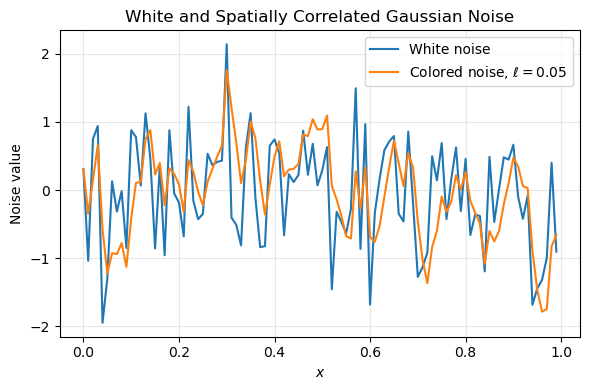

In [10]:
plt.figure(figsize=(6, 4))

plt.plot(
    x,
    white_sample,
    label="White noise",
)

plt.plot(
    x,
    colored_sample,
    label=rf"Colored noise, $\ell={ell_selected}$",
)

plt.xlabel(r"$x$")
plt.ylabel("Noise value")
plt.title("White and Spatially Correlated Gaussian Noise")

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Influence of the Correlation Length

Using the same underlying Gaussian sample, we generate colored noise for several correlation lengths.

Increasing the correlation length strengthens the spatial dependence between neighboring locations.

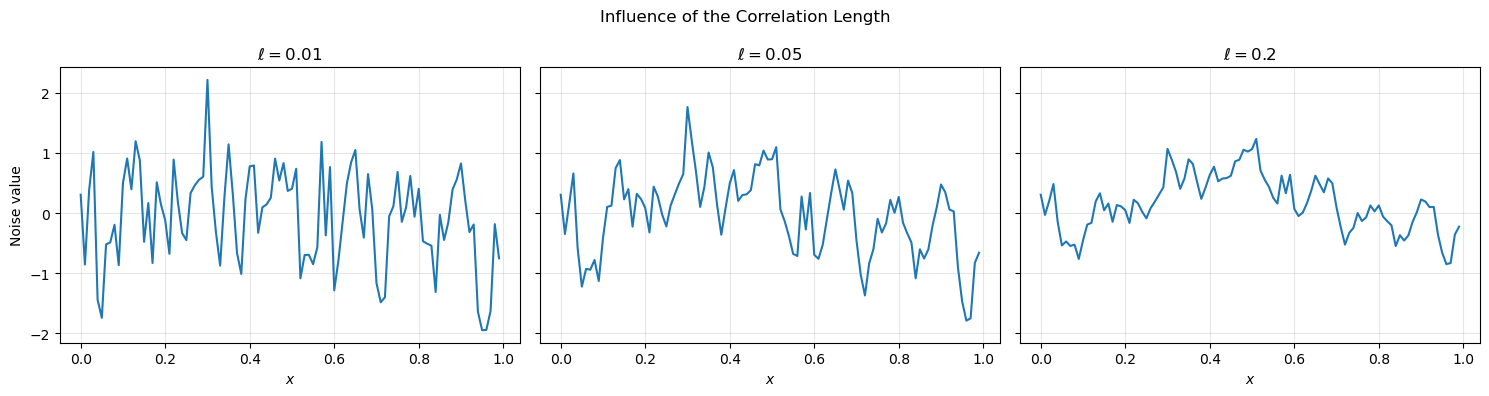

In [11]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4),
    sharey=True,
)

for ax, ell in zip(axes, ells):
    ax.plot(
        x,
        colored_samples[ell],
    )

    ax.set_title(rf"$\ell={ell}$")
    ax.set_xlabel(r"$x$")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Noise value")

fig.suptitle("Influence of the Correlation Length")
plt.tight_layout()

plt.savefig(
    "figures/correlation_length_comparison.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

### Numerical Covariance Verification

To verify the correctness of the construction, we generate many independent realizations of the correlated Gaussian field and estimate the empirical covariance matrix.

The empirical covariance is then compared with the prescribed theoretical covariance.

In [12]:
verification_ell = 0.05
num_covariance_samples = 5000

Q_theoretical = covariance_matrices[verification_ell]
L_verification = cholesky_factors[verification_ell]

rng = np.random.default_rng(123)

white_samples = rng.normal(
    size=(num_covariance_samples, N)
)

colored_samples_mc = np.array([
    generate_colored_noise(
        L_verification,
        white_sample,
    )
    for white_sample in white_samples
])

In [13]:
Q_empirical = np.cov(
    colored_samples_mc,
    rowvar=False,
    bias=True,
)

### Covariance Matrices

The following figure compares the theoretical covariance matrix with the empirical covariance matrix estimated from Monte Carlo samples.

Agreement between the two matrices confirms that the Cholesky transformation produces Gaussian samples with the desired covariance.

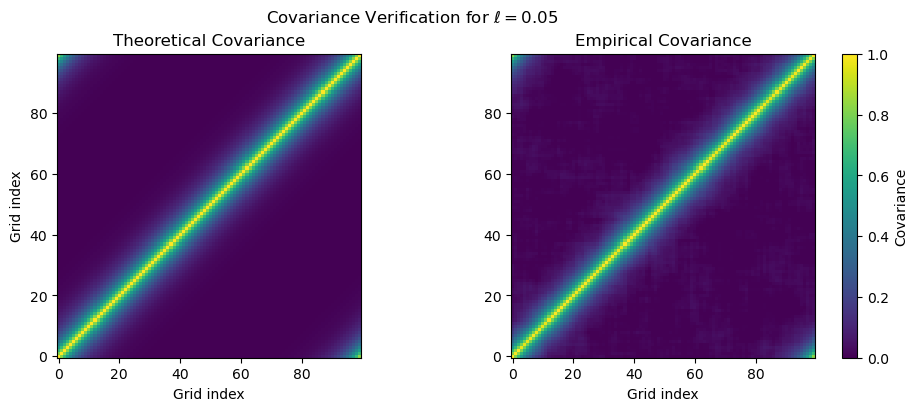

In [14]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 4),
    constrained_layout=True,
)

matrices = [
    Q_theoretical,
    Q_empirical,
]

titles = [
    "Theoretical Covariance",
    "Empirical Covariance",
]

for ax, matrix, title in zip(
    axes,
    matrices,
    titles,
):
    image = ax.imshow(
        matrix,
        origin="lower",
        aspect="equal",
        vmin=0,
        vmax=1,
    )

    ax.set_title(title)
    ax.set_xlabel("Grid index")

axes[0].set_ylabel("Grid index")

fig.colorbar(
    image,
    ax=axes,
    fraction=0.04,
    pad=0.03,
    label="Covariance",
)

fig.suptitle(
    rf"Covariance Verification for $\ell={verification_ell}$"
)

plt.show()

### Covariance Profiles

Finally, we compare the theoretical and empirical covariance profiles.

The empirical profile closely follows the prescribed exponential covariance, with small deviations caused by the finite number of Monte Carlo samples.

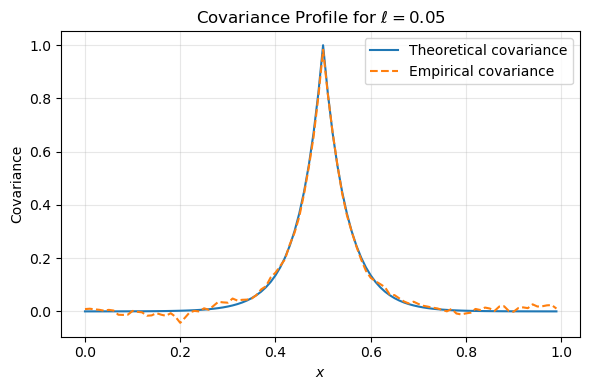

In [15]:
reference_index = N // 2

plt.figure(figsize=(6, 4))

plt.plot(
    x,
    Q_theoretical[reference_index],
    label="Theoretical covariance",
)

plt.plot(
    x,
    Q_empirical[reference_index],
    linestyle="--",
    label="Empirical covariance",
)

plt.xlabel(r"$x$")
plt.ylabel("Covariance")
plt.title(
    rf"Covariance Profile for $\ell={verification_ell}$"
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Summary

In this notebook, we introduced spatially correlated Gaussian noise and constructed Gaussian random fields with a prescribed covariance matrix using the Cholesky decomposition.

We investigated the influence of the correlation length on the covariance structure and the resulting random fields, and verified numerically that the generated samples reproduce the desired covariance.

In the next notebook, we will use these correlated Gaussian fields to drive the stochastic heat equation and investigate how spatial correlation influences the numerical solution.